## 목차

1. [환경설정](#1-환경설정)
2. [데이터 구조 파악](#2-데이터-구조-파악)
3. [데이터 전처리](#3-데이터-전처리)
4. [EDA](#4-eda)

# 1. 환경설정

In [1]:
# 필요 라이브러리 설치
!pip install -q gdown

In [2]:
# gdown 다운로드 테스트 (단일 파일)
import gdown

file_id = ""

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "site_area.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=
To: /content/site_area.csv
1.70kB [00:00, 2.43MB/s]


'site_area.csv'

In [3]:
# 원본 CSV 파일들 Google Drive에서 다운로드
import gdown

files = {
    "site_area.csv": "1tqjCywUBX7ivID62rDJ19ZchQmkLmCmr",
    "trial_access_log.csv": "17_VUATpRUGn7wcmkUkUcFmUQmkA9S0wb",
    "trial_payment.csv": "1OM2pDtVaq6vG-JcoilOunfETUtdLeZWN",
    "trial_register.csv": "1zbjXQMB6jJzJa0seEL0jUwuiRCYGQXFl",
    "trial_visit_info.csv": "1-hNqJ1aoHfqaDJV-WaLsXvf6nk_BNUD0"
}

for filename, file_id in files.items():
    gdown.download(
        f"https://drive.google.com/uc?id={file_id}",
        filename,
        quiet=False
    )

Downloading...
From: https://drive.google.com/uc?id=1tqjCywUBX7ivID62rDJ19ZchQmkLmCmr
To: /content/site_area.csv
100%|██████████| 81.0/81.0 [00:00<00:00, 255kB/s]
Downloading...
From: https://drive.google.com/uc?id=17_VUATpRUGn7wcmkUkUcFmUQmkA9S0wb
To: /content/trial_access_log.csv
100%|██████████| 4.81M/4.81M [00:00<00:00, 31.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OM2pDtVaq6vG-JcoilOunfETUtdLeZWN
To: /content/trial_payment.csv
100%|██████████| 377k/377k [00:00<00:00, 7.26MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zbjXQMB6jJzJa0seEL0jUwuiRCYGQXFl
To: /content/trial_register.csv
100%|██████████| 464k/464k [00:00<00:00, 7.56MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-hNqJ1aoHfqaDJV-WaLsXvf6nk_BNUD0
To: /content/trial_visit_info.csv
100%|██████████| 1.40M/1.40M [00:00<00:00, 15.9MB/s]


In [4]:
# 데이터프레임으로 로드 (지점 면적/출입기록/결제/신청/방문기록)
import pandas as pd

area_df = pd.read_csv('site_area.csv')
access_log_df = pd.read_csv('trial_access_log.csv')
payment_log_df = pd.read_csv('trial_payment.csv')
register_df = pd.read_csv('trial_register.csv')
visit_info_df = pd.read_csv('trial_visit_info.csv')

In [5]:
# 한글 폰트 설정을 위한 라이브러리 설치 및 임포트
!pip install koreanize-matplotlib -q
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 24.4 MB/s eta 0:00:00


# 2. 데이터 구조 파악

- trial_register : 3일체험 신청 (3일 체험은 유저 당 1회만 제공)
- trial_visit_info : 3일체험 신청자 일자별 방문기록
- trial_access_log : 3일체험 신청자 출입기록
- trial_payment : 3일체험 신청자 결제 여부
- site_area : 지점별 면적

## access_log (3일체험 신청자 출입기록)

In [6]:
# access_log 데이터 미리보기
access_log_df.head() # utc

,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
3,1716588,1,2023-07-06 13:09:48.758097,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
4,1719649,1,2023-07-07 10:12:42.083352,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


In [7]:
# access_log 컬럼 구조 확인
access_log_df.info()

# cdate: 출입 로그 생성 시간
# checkin: (입실: 1, 퇴실: 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63708 entries, 0 to 63707
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         63708 non-null  int64 
 1   checkin    63708 non-null  int64 
 2   cdate      63708 non-null  object
 3   site_id    63708 non-null  int64 
 4   user_uuid  63708 non-null  object
dtypes: int64(3), object(2)
memory usage: 2.4+ MB


In [8]:
# cdate utc -> kst 변환
access_log_df['cdate'] = pd.to_datetime(access_log_df['cdate'], utc=True) # utc 맞는지 확실하게 체크
access_log_df['cdate'] = access_log_df['cdate'].dt.tz_convert('Asia/Seoul') # utc -> kst 변환

In [9]:
# 중복 확인 전 데이터 재확인
access_log_df.head()

,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 16:11:55.201673+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-07 00:15:58.761284+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 23:10:41.848998+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
3,1716588,1,2023-07-06 22:09:48.758097+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
4,1719649,1,2023-07-07 19:12:42.083352+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


In [10]:
# checkin 값 종류 확인
access_log_df['checkin'].unique()

array([1, 2])

In [11]:
# checkin 값별 건수 확인
access_log_df['checkin'].value_counts()

,count
checkin,
1,32144
2,31564


In [12]:
# 지점 ID 종류 확인
access_log_df['site_id'].unique()

array([49,  1, 17,  3,  6,  2,  4,  5, 47])

In [13]:
# 지점별 출입 건수 확인 (면적 대비 밀집도 파악)
access_log_df['site_id'].value_counts().sort_values(ascending=False) # 3, 6번이 많지만, 평수도 크다. 1번이 면적에 비해 사람이 많다.
# 50평: 1, 17, 47, 49
# 100평: 2, 4
# 150평: 3, 5, 6

,count
site_id,
3,17125
6,14038
1,7421
2,6392
5,6308
4,4497
17,3870
47,2717
49,1340


In [14]:
# access_log 고유 유저 수 확인
access_log_df['user_uuid'].nunique()

6026

In [15]:
# id 컬럼 중복 여부 확인
access_log_df['id'].duplicated().sum() # id 중복 존재

np.int64(359)

In [16]:
# 1. checkin 입/퇴실 숫자 안맞는다 (누락이 있을수도??)
# 2. id값에 중복값이 존재한다 (359)

## visit_info (3일체험 신청자 일자별 방문기록)

In [17]:
# visit_info 데이터 미리보기
visit_info_df.head()
# stay_time = 해당 날의 실제 머문 시간(중간퇴실, 외출 반영)

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594


In [18]:
# visit_info 컬럼 구조 확인
visit_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11477 entries, 0 to 11476
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   site_id           11477 non-null  int64 
 1   date              11477 non-null  object
 2   stay_time         11477 non-null  object
 3   stay_time_second  11477 non-null  int64 
 4   first_enter_time  10922 non-null  object
 5   last_leave_time   10922 non-null  object
 6   user_uuid         11477 non-null  object
dtypes: int64(2), object(5)
memory usage: 627.8+ KB


In [20]:
# visit_info 기초 통계량 확인
visit_info_df.describe()

,site_id,stay_time_second
count,11477.000000,11477.000000
mean,7.502832,16689.460922
std,11.608720,11968.841154
min,1.000000,1.000000
25%,2.000000,7776.000000
50%,4.000000,14699.000000
75%,6.000000,23326.000000
max,49.000000,86377.000000


In [21]:
# visit_info 중복 행 수 확인
visit_info_df.duplicated().sum()

np.int64(48)

In [22]:
# 방문 시간 컬럼 결측치 수 확인
visit_info_df.first_enter_time.isnull().sum(), visit_info_df.last_leave_time.isnull().sum()

(np.int64(555), np.int64(555))

In [23]:
# first_enter_time 중 밀리초 단위 없는 값 개수 확인
no_ms_mask = ~visit_info_df['first_enter_time'].dropna().str.contains(r'\.', regex=True)
no_ms_mask.sum()

np.int64(798)

In [24]:
# last_leave_time 중 밀리초 단위 없는 값 개수 확인
no_ms_mask = ~visit_info_df['last_leave_time'].dropna().str.contains(r'\.', regex=True)
no_ms_mask.sum()

np.int64(775)

In [25]:
# first_enter_time, last_leave_time 결측
# - ms 단위 결측 : 자를까? (format 통일 필요, datetime 변환시 사용)
# - 완전 빈값 : access_log 참고해서 집어 넣기 : 555개 (더 알아보자, 조인)
# 완전 중복 48개

## payment_log (3일체험 신청자 결제 여부)

In [26]:
# payment_log 데이터 미리보기
payment_log_df.head()

,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0


In [27]:
# payment_log 컬럼 구조 확인
payment_log_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   is_payment  9659 non-null   int64 
 1   user_uuid   9659 non-null   object
dtypes: int64(1), object(1)
memory usage: 151.1+ KB


In [ ]:
# payment_log 중복 행 수 확인
payment_log_df.duplicated().sum() # 중복
# 완전 중복 건 35개

np.int64(35)

In [29]:
# payment_log 고유 유저 수 확인
payment_log_df['user_uuid'].nunique()

9624

In [30]:
# payment_log 기초 통계량 확인 (결제 비율 파악)
payment_log_df.describe() # 결제 비율 37% -> 중복 삭제 후 보기

,is_payment
count,9659.000000
mean,0.379335
std,0.485247
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


## register (3일체험 신청)

In [32]:
# register 데이터 미리보기
register_df.head()

,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0


In [33]:
# register 컬럼 구조 확인
register_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   trial_date  9659 non-null   object
 1   user_uuid   9659 non-null   object
dtypes: object(2)
memory usage: 151.1+ KB


In [34]:
# register 중복 행 수 확인
register_df.duplicated().sum()

np.int64(28)

In [35]:
# register 고유 유저 수 확인
register_df['user_uuid'].nunique()

9624

In [36]:
# 신청일자별 건수 확인
register_df['trial_date'].value_counts() # 2022-12-08

,count
trial_date,
2022-12-08,144
2022-01-30,62
2022-08-07,54
2022-10-04,41
2022-12-12,39
...,...
2022-12-18,1
2022-10-29,1
2021-12-13,1


In [37]:
# 중복 28
# register에 없는게 visit info, access log에 있을수도?

## area (지점별 면적)

In [38]:
# area 데이터 미리보기
area_df

,site_id,area_pyeong
0,1,50
1,2,100
2,3,150
3,4,100
4,5,150
5,6,150
6,17,50
7,47,50
8,49,50


In [39]:
# area 컬럼 구조 확인
area_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   site_id      9 non-null      int64
 1   area_pyeong  9 non-null      int64
dtypes: int64(2)
memory usage: 276.0 bytes


# 3. 데이터 전처리

### access_log 에서 중복값 제거

In [40]:
# 중복 제거 전 행 수 확인
access_log_df.shape

(63708, 5)

In [41]:
# 중복 행 수 확인
access_log_df.duplicated().sum() # access_log_df 중복값 제거

np.int64(359)

In [42]:
# 중복 행 제거
access_log_df.drop_duplicates(keep='last', inplace=True)

In [43]:
# 중복 제거 후 행 수 확인
access_log_df.shape

(63349, 5)

### visit_info 에서 중복값 제거

In [44]:
# 중복 제거 전 행 수 확인
visit_info_df.shape

(11477, 7)

In [45]:
# 중복 행 수 확인
visit_info_df.duplicated().sum() # visit_info_df 중복값 제거

np.int64(48)

In [46]:
# 중복 행 제거
visit_info_df.drop_duplicates(keep='last', inplace=True)

In [47]:
# 중복 제거 후 행 수 확인
visit_info_df.shape

(11429, 7)

### payment 에서 중복값 제거

In [48]:
# 중복 제거 전 행 수 확인
payment_log_df.shape

(9659, 2)

In [49]:
# 중복 행 수 확인
payment_log_df.duplicated().sum() # payment_log_df 중복값 제거

np.int64(35)

In [50]:
# 중복 행 제거
payment_log_df.drop_duplicates(keep='last', inplace=True)

In [51]:
# 중복 제거 후 행 수 확인
payment_log_df.shape

(9624, 2)

### register 에서 중복값 제거

In [52]:
# 중복 제거 전 행 수 확인
register_df.shape

(9659, 2)

In [53]:
# 중복 행 수 확인
register_df.duplicated().sum() # register_df 중복값 제거

np.int64(28)

In [54]:
# 중복 행 제거
register_df.drop_duplicates(keep='last', inplace=True)

In [55]:
# 중복 제거 후 행 수 확인
register_df.shape

(9631, 2)

### 모수 설정

- 프로젝트 모수 정의 : register 와 payment_log에 모두 기록이 있는 유저

In [56]:
# register와 payment_log의 고유 유저 집합 일치 여부 확인 (모수 설정)
set(register_df['user_uuid'].unique()) == set(payment_log_df['user_uuid'].unique())
# register_df uuid 와 payment_log_df uuid unique 수가 일치하는지 확인 (모수 설정을 위함)

True

In [57]:
# register/payment_log 행 수 비교
register_df.shape, payment_log_df.shape

((9631, 2), (9624, 2))

In [58]:
# register에서 중복된 user_uuid(중복 신청자) 확인
register_df[register_df['user_uuid'].duplicated(keep=False)] # register 중복 인원 7명

,trial_date,user_uuid
835,2021-06-16,ffd880d5-0200-44e1-91db-7df9483f2a39
836,2021-06-28,ffd880d5-0200-44e1-91db-7df9483f2a39
1682,2021-09-06,4008307f-486f-408f-b90b-e01398972029
1683,2022-03-25,4008307f-486f-408f-b90b-e01398972029
3461,2022-03-04,bf620970-e3f2-4b54-9620-86171299d08b
3462,2021-10-28,bf620970-e3f2-4b54-9620-86171299d08b
3554,2022-03-14,5b16f32b-3344-4b39-b2bf-8cf1caac78fa
3555,2023-03-22,5b16f32b-3344-4b39-b2bf-8cf1caac78fa
4674,2022-08-02,bd3ed6c2-f139-4e0c-b53e-b956101b2822
4675,2022-10-21,bd3ed6c2-f139-4e0c-b53e-b956101b2822


In [59]:
# 중복 신청자의 user_uuid 목록 확인
register_df[register_df['user_uuid'].duplicated()]['user_uuid']

,user_uuid
836,ffd880d5-0200-44e1-91db-7df9483f2a39
1683,4008307f-486f-408f-b90b-e01398972029
3462,bf620970-e3f2-4b54-9620-86171299d08b
3555,5b16f32b-3344-4b39-b2bf-8cf1caac78fa
4675,bd3ed6c2-f139-4e0c-b53e-b956101b2822
4969,6a88014b-fbbd-4e73-8036-04435c062a97
5625,14872783-3af7-492a-b51c-12f3003b76f1


In [60]:
# 중복 제거 전 register 행 수 확인
register_df.shape

(9631, 2)

In [61]:
# register 데이터 재확인
register_df.head()

,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0


In [62]:
# user_uuid 중복 시 최신 신청 기록만 유지
register_df = register_df.sort_values('trial_date').drop_duplicates(subset=['user_uuid'], keep='last') # 마지막(최근) 데이터만 남기기

In [63]:
# 최종 모수(register/payment_log) 행 수 확인
register_df.shape, payment_log_df.shape # 모수 = 9624

((9624, 2), (9624, 2))

### register datetime 타입으로 전환

In [64]:
# datetime 변환 전 컬럼 타입 확인
register_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9624 entries, 427 to 102
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   trial_date  9624 non-null   object
 1   user_uuid   9624 non-null   object
dtypes: object(2)
memory usage: 225.6+ KB


In [65]:
# trial_date 컬럼 값 확인
register_df.head(3)

,trial_date,user_uuid
427,2021-05-01,badbde4d-886b-4992-a8e3-fd0c05640183
425,2021-05-01,e079e682-62f2-4c05-84b9-86913e3dc146
428,2021-05-01,f25078d1-1030-485c-85c5-dc82d6987043


In [66]:
# trial_date를 datetime 타입으로 변환
register_df['trial_date'] = pd.to_datetime(register_df['trial_date'])

In [67]:
# 변환 후 컬럼 타입 재확인
register_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9624 entries, 427 to 102
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   trial_date  9624 non-null   datetime64[ns]
 1   user_uuid   9624 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 483.6+ KB


### access_log datetime 타입으로 전환

In [68]:
# datetime 변환 전 컬럼 타입 확인
access_log_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63349 entries, 0 to 63707
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype                     
---  ------     --------------  -----                     
 0   id         63349 non-null  int64                     
 1   checkin    63349 non-null  int64                     
 2   cdate      63349 non-null  datetime64[ns, Asia/Seoul]
 3   site_id    63349 non-null  int64                     
 4   user_uuid  63349 non-null  object                    
dtypes: datetime64[ns, Asia/Seoul](1), int64(3), object(1)
memory usage: 2.9+ MB


In [69]:
# cdate 컬럼 값 확인
access_log_df.head(3)

,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 16:11:55.201673+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-07 00:15:58.761284+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 23:10:41.848998+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


In [70]:
# cdate를 datetime 타입으로 변환 (초 단위 반올림)
access_log_df['cdate'] = pd.to_datetime(access_log_df['cdate'], format='%Y-%m-%d %H:%M:%S', exact=False)
access_log_df['cdate'] = pd.to_datetime(access_log_df['cdate']).dt.floor('s')

In [71]:
# 변환 후 컬럼 타입 재확인
access_log_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63349 entries, 0 to 63707
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype                     
---  ------     --------------  -----                     
 0   id         63349 non-null  int64                     
 1   checkin    63349 non-null  int64                     
 2   cdate      63349 non-null  datetime64[ns, Asia/Seoul]
 3   site_id    63349 non-null  int64                     
 4   user_uuid  63349 non-null  object                    
dtypes: datetime64[ns, Asia/Seoul](1), int64(3), object(1)
memory usage: 2.9+ MB


In [72]:
# 변환된 cdate 값 확인
access_log_df.head(3)

,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 16:11:55+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-07 00:15:58+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 23:10:41+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


### visit_info datetime 타입으로 전환

In [73]:
# datetime 변환 전 컬럼 타입 확인
visit_info_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11429 entries, 0 to 11476
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   site_id           11429 non-null  int64 
 1   date              11429 non-null  object
 2   stay_time         11429 non-null  object
 3   stay_time_second  11429 non-null  int64 
 4   first_enter_time  10874 non-null  object
 5   last_leave_time   10874 non-null  object
 6   user_uuid         11429 non-null  object
dtypes: int64(2), object(5)
memory usage: 714.3+ KB


In [74]:
# first_enter_time/last_leave_time 값 확인
visit_info_df.head(3)

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73


In [75]:
# first_enter_time, last_leave_time을 datetime 타입으로 변환
visit_info_df['first_enter_time'] = pd.to_datetime(visit_info_df['first_enter_time'], format='%Y-%m-%d %H:%M:%S', exact=False)
visit_info_df['first_enter_time'] = pd.to_datetime(visit_info_df['first_enter_time']).dt.floor('s')

visit_info_df['last_leave_time'] = pd.to_datetime(visit_info_df['last_leave_time'], format='%Y-%m-%d %H:%M:%S', exact=False)
visit_info_df['last_leave_time'] = pd.to_datetime(visit_info_df['last_leave_time']).dt.floor('s')

visit_info_df['stay_time'] = pd.to_timedelta(visit_info_df['stay_time']).dt.floor('s')


In [76]:
# 변환 후 값 확인
visit_info_df.head(3)

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,0 days 01:11:19,4279,2023-12-23 16:11:25,2023-12-23 17:25:32,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,0 days 04:35:10,16510,2023-12-24 16:10:45,2023-12-24 20:53:34,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,0 days 02:09:54,7794,2023-12-25 10:19:47,2023-12-25 12:39:51,939fc566-61cd-47f0-a3ce-e2936fdcff73


### 모수에는 존재하는데 access_log, visit_info 존재하는 uuid 추적

In [77]:
# register 모수 유저 수 확인
register_df['user_uuid'].shape

(9624,)

In [78]:
# access_log, visit_info 고유 유저 수 비교
access_log_df['user_uuid'].nunique(), visit_info_df['user_uuid'].nunique()

(6026, 6534)

In [79]:
# access_log와 visit_info 고유 유저 수 차이 확인
abs((access_log_df['user_uuid'].nunique())- (visit_info_df['user_uuid'].nunique()))

508

In [80]:
# access_log에는 있는데 register에는 없는 uuid
access_log_df[~access_log_df['user_uuid'].isin(register_df['user_uuid'])]['user_uuid'].nunique()

0

In [81]:
# visit에는 있는데 access에는 없는 uuid
visit_info_df[~visit_info_df['user_uuid'].isin(access_log_df['user_uuid'])]['user_uuid'].nunique()

511

In [82]:
# access_log에는 있는데 visit에는 없는 uuid
access_log_df[~access_log_df['user_uuid'].isin(visit_info_df['user_uuid'])]['user_uuid'].unique()
# 511 - 508 = 3
# 결론 : known으로 일단 넘김

array(['06ed9e12-7ed9-462b-9c1b-3c3fc4e229f9',
       'fe55f5e4-4027-4860-b3c7-1338b18846d0',
       '070ff794-9409-447c-9889-f463e1acb1a3'], dtype=object)

In [83]:
# visit에는 있는데 register에는 없는 uuid
visit_info_df[~visit_info_df['user_uuid'].isin(register_df['user_uuid'])]['user_uuid'].nunique()

0

In [85]:
# access_log_df에서 'cdate'의 날짜 부분만 추출하여 'date' 컬럼을 생성하고, timezone을 제거합니다.
access_log_df['date'] = access_log_df['cdate'].dt.date.astype('datetime64[ns]')
access_log_df['cdate_naive'] = access_log_df['cdate'].dt.tz_localize(None)

In [86]:
# access_log_df에서 first_enter_time (checkin == 1)을 계산합니다.
access_first_enter = access_log_df[access_log_df['checkin'] == 1].groupby(['user_uuid', 'date'])['cdate_naive'].min().reset_index()
access_first_enter.rename(columns={'cdate_naive': 'new_first_enter_time'}, inplace=True)

In [87]:
# access_log_df에서 last_leave_time (checkin == 2)을 계산합니다.
access_last_leave = access_log_df[access_log_df['checkin'] == 2].groupby(['user_uuid', 'date'])['cdate_naive'].max().reset_index()
access_last_leave.rename(columns={'cdate_naive': 'new_last_leave_time'}, inplace=True)

In [88]:
# 보강한 first_enter_time/last_leave_time을 visit_info_df에 병합
visit_info_df['date'] = pd.to_datetime(visit_info_df['date'])
# visit_info_df에 계산된 first_enter_time과 last_leave_time을 병합합니다.
visit_info_df = visit_info_df.merge(access_first_enter, on=['user_uuid', 'date'], how='left')
visit_info_df = visit_info_df.merge(access_last_leave, on=['user_uuid', 'date'], how='left')

In [89]:
#. 기존 first_enter_time, last_leave_time 컬럼의 결측치를 병합된 값으로 채웁니다.
visit_info_df['first_enter_time'] = visit_info_df['first_enter_time'].fillna(visit_info_df['new_first_enter_time'])
visit_info_df['last_leave_time'] = visit_info_df['last_leave_time'].fillna(visit_info_df['new_last_leave_time'])

# 임시로 생성된 컬럼들을 삭제합니다.
visit_info_df.drop(columns=['new_first_enter_time', 'new_last_leave_time'], inplace=True)
access_log_df.drop(columns=['date', 'cdate_naive'], inplace=True)

In [90]:
# 결측치 확인
print(visit_info_df['first_enter_time'].isnull().sum())
print(visit_info_df['last_leave_time'].isnull().sum())

# 변경된 visit_info_df의 상위 5행을 출력합니다.
display(visit_info_df.head())

75
72


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,0 days 01:11:19,4279,2023-12-23 16:11:25,2023-12-23 17:25:32,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,0 days 04:35:10,16510,2023-12-24 16:10:45,2023-12-24 20:53:34,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,0 days 02:09:54,7794,2023-12-25 10:19:47,2023-12-25 12:39:51,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,0 days 04:37:36,16656,2023-12-23 14:49:40,2023-12-23 19:27:39,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,0 days 04:32:05,16325,2023-12-26 14:57:10,2023-12-26 19:34:36,ba49324f-d317-4053-adf9-2b17b3f07594


### visit_info와 access_log 간의 user_uuid 불일치 해소

`visit_info_df`에만 있거나 `access_log_df`에만 있는 `user_uuid`들을 식별하여 모든 데이터프레임(`access_log_df`, `visit_info_df`, `payment_log_df`, `register_df`)에서 해당 `user_uuid`를 가진 행을 제거합니다. 이는 두 핵심 로그 데이터 간의 불일치를 해소하여 분석의 일관성을 유지하기 위함입니다.

In [91]:
# visit_info_df에만 있고 access_log_df에는 없는 user_uuid 찾기
visit_only_uuids = set(visit_info_df['user_uuid'].unique()) - set(access_log_df['user_uuid'].unique())

# access_log_df에만 있고 visit_info_df에는 없는 user_uuid 찾기
access_only_uuids = set(access_log_df['user_uuid'].unique()) - set(visit_info_df['user_uuid'].unique())

# 제거할 user_uuid 목록 결합
uuids_to_remove = visit_only_uuids.union(access_only_uuids)

print(f"visit_info_df에만 있는 user_uuid 수: {len(visit_only_uuids)}")
print(f"access_log_df에만 있는 user_uuid 수: {len(access_only_uuids)}")
print(f"총 제거할 user_uuid 수: {len(uuids_to_remove)}")

visit_info_df에만 있는 user_uuid 수: 511
access_log_df에만 있는 user_uuid 수: 3
총 제거할 user_uuid 수: 514


In [92]:
# 모든 데이터프레임에서 해당 user_uuid를 제거합니다.
access_log_df = access_log_df[~access_log_df['user_uuid'].isin(uuids_to_remove)]
visit_info_df = visit_info_df[~visit_info_df['user_uuid'].isin(uuids_to_remove)]
payment_log_df = payment_log_df[~payment_log_df['user_uuid'].isin(uuids_to_remove)]
register_df = register_df[~register_df['user_uuid'].isin(uuids_to_remove)]

print("불일치하는 user_uuid 제거 후 데이터프레임별 user_uuid 수:")
print(f"access_log_df: {access_log_df['user_uuid'].nunique()}")
print(f"visit_info_df: {visit_info_df['user_uuid'].nunique()}")
print(f"payment_log_df: {payment_log_df['user_uuid'].nunique()}")
print(f"register_df: {register_df['user_uuid'].nunique()}")

불일치하는 user_uuid 제거 후 데이터프레임별 user_uuid 수:
access_log_df: 6023
visit_info_df: 6023
payment_log_df: 9110
register_df: 9110


💡 access_log/visit_info 간 불일치 user_uuid 514명(방문기록만 있는 511명 + 출입기록만 있는 3명)을 전 데이터프레임에서 제거해 최종 모수를 방문기록 기준 6,023명, 전체 신청자 기준 9,110명으로 확정

# 4. EDA

## 결제자 비율

In [93]:
# 결제자 비율 확인 (클래스 불균형 파악)
payment_log_df['is_payment'].value_counts() / len(payment_log_df['is_payment']) # 불균형 데이터 확인

,count
is_payment,
0,0.62404
1,0.37596


💡 결제 전환율은 37.6%(미전환 62.4%)로 클래스 불균형

## 기간별 신청자 특성

### 연도별

In [94]:
# 신청일에서 연도 추출
register_df['trial_date_year'] = register_df['trial_date'].dt.year

/tmp/ipykernel_4072/2990427552.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Number of Applicants', data=applicants_by_year, palette='viridis')


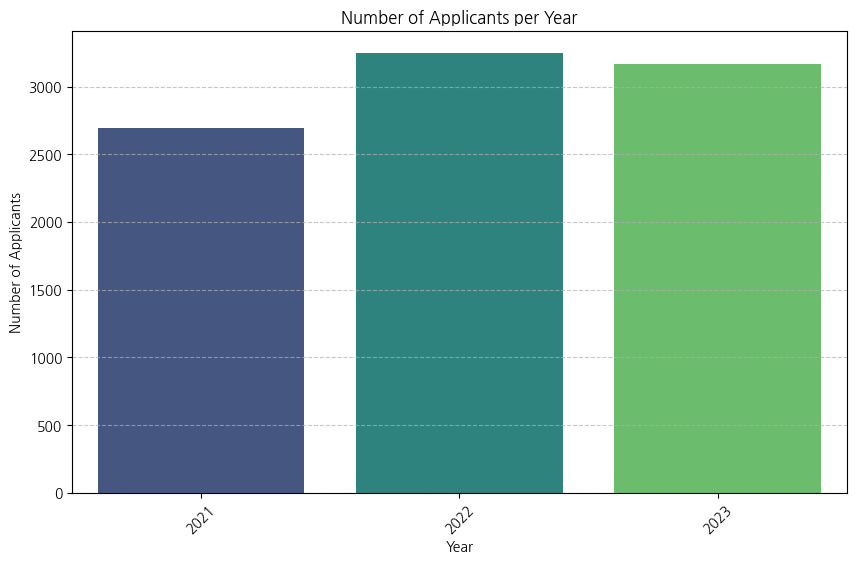

In [95]:
# 연도별 신규 신청자 수 시각화
import matplotlib.pyplot as plt
import seaborn as sns
applicants_by_year = register_df.groupby('trial_date_year')['user_uuid'].nunique().reset_index()
applicants_by_year.columns = ['Year', 'Number of Applicants']

plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Number of Applicants', data=applicants_by_year, palette='viridis')
plt.title('Number of Applicants per Year')
plt.xlabel('Year')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 월별 신청자

In [96]:
# 신청일에서 월 추출
register_df['trial_date_month'] = register_df['trial_date'].dt.month

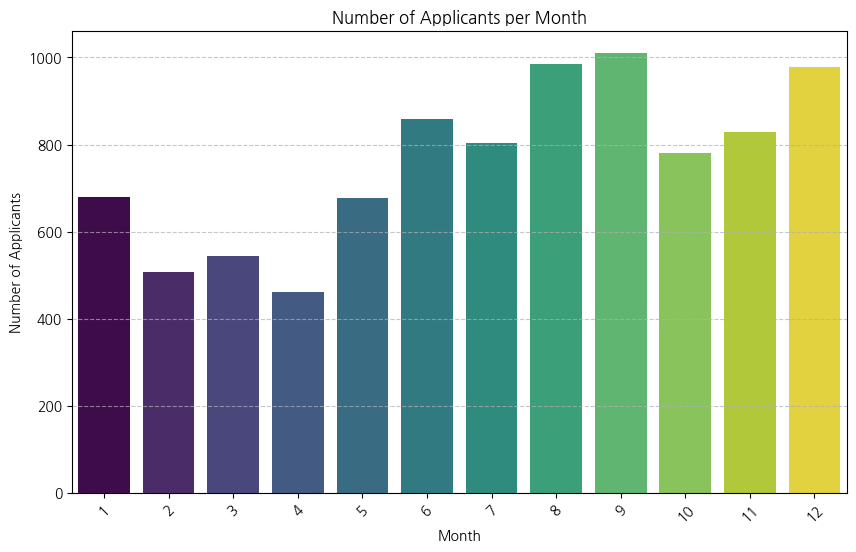

In [97]:
# 월별 신규 신청자 수 시각화
import matplotlib.pyplot as plt
import seaborn as sns

applicants_by_month = register_df.groupby('trial_date_month')['user_uuid'].nunique().reset_index()
applicants_by_month.columns = ['Month', 'Number of Applicants']

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Number of Applicants', data=applicants_by_month, palette='viridis', hue='Month', legend=False)
plt.title('Number of Applicants per Month')
plt.xlabel('Month')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 연,월별 신청자

In [98]:
# 신청일에서 연-월 문자열 추출
register_df['trial_date_y_m'] = register_df['trial_date'].dt.strftime('%Y-%m')

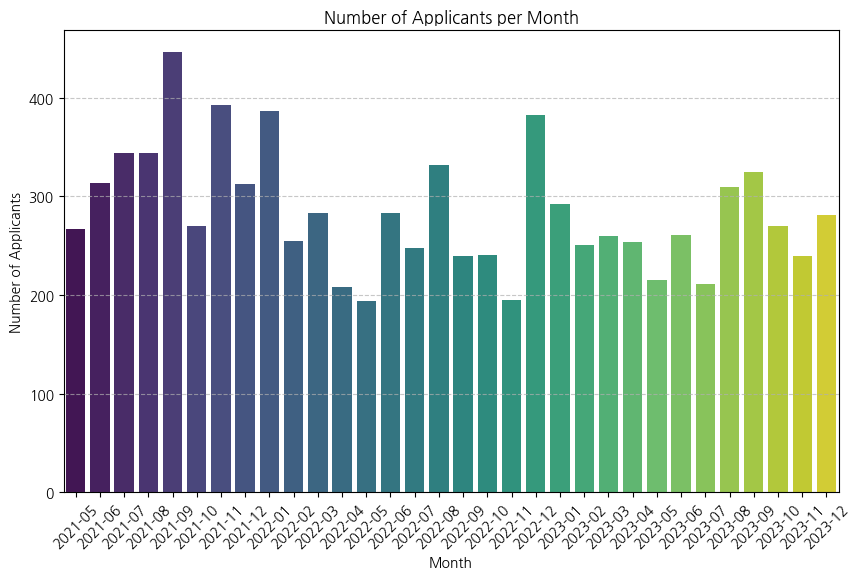

In [99]:
# 연-월별 신규 신청자 수 시각화
applicants_by_month = register_df.groupby('trial_date_y_m')['user_uuid'].nunique().reset_index()
applicants_by_month.columns = ['Month', 'Number of Applicants']

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Number of Applicants', data=applicants_by_month, palette='viridis', hue='Month', legend=False)
plt.title('Number of Applicants per Month')
plt.xlabel('Month')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 분기별 신청자

In [100]:
# 신청일에서 분기 추출
register_df['trial_date_quarter'] = register_df['trial_date'].dt.quarter

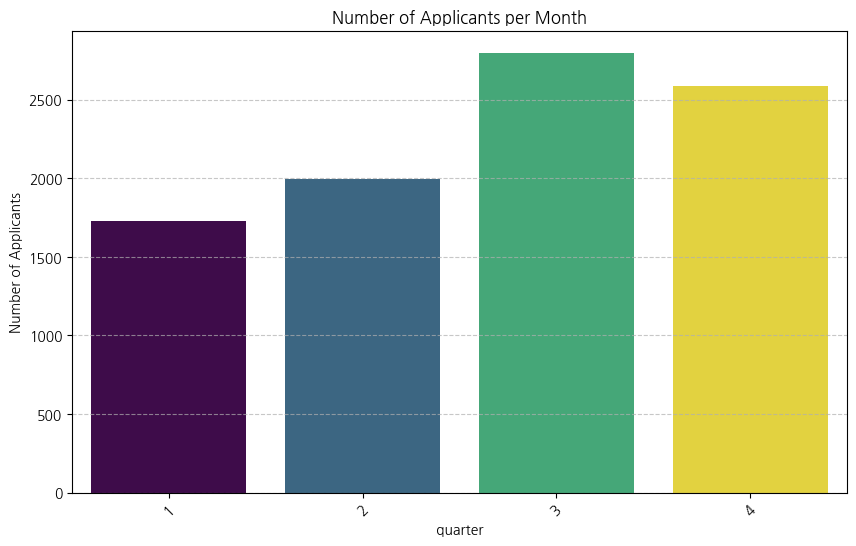

In [101]:
# 분기별 신규 신청자 수 시각화
applicants_by_month = register_df.groupby('trial_date_quarter')['user_uuid'].nunique().reset_index()
applicants_by_month.columns = ['Month', 'Number of Applicants']

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Number of Applicants', data=applicants_by_month, palette='viridis', hue='Month', legend=False)
plt.title('Number of Applicants per Month')
plt.xlabel('quarter')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [102]:
# 신청일에서 연-분기 기간 추출
register_df['trial_quarter'] = register_df['trial_date'].dt.to_period('Q')

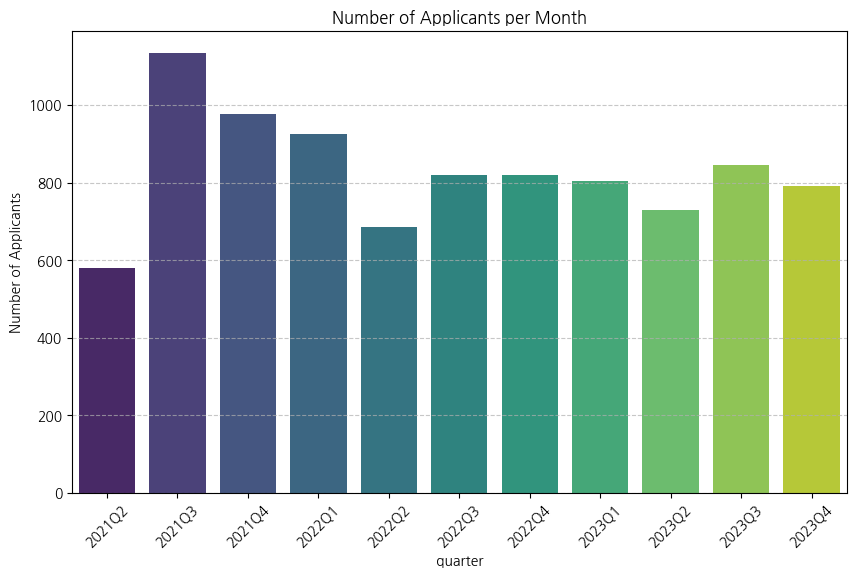

In [103]:
# 연-분기별 신규 신청자 수 시각화
applicants_by_month = register_df.groupby('trial_quarter')['user_uuid'].nunique().reset_index()
applicants_by_month.columns = ['Month', 'Number of Applicants']

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Number of Applicants', data=applicants_by_month, palette='viridis', hue='Month', legend=False)
plt.title('Number of Applicants per Month')
plt.xlabel('quarter')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 요일별 신청자

In [104]:
# 신청일에서 요일 추출 및 한글 매핑
register_df['trial_weekday'] = register_df['trial_date'].dt.weekday
weekday_map = {
    0: '월',
    1: '화',
    2: '수',
    3: '목',
    4: '금',
    5: '토',
    6: '일'
}

register_df['trial_weekday'] = register_df['trial_date'].dt.weekday.map(weekday_map)

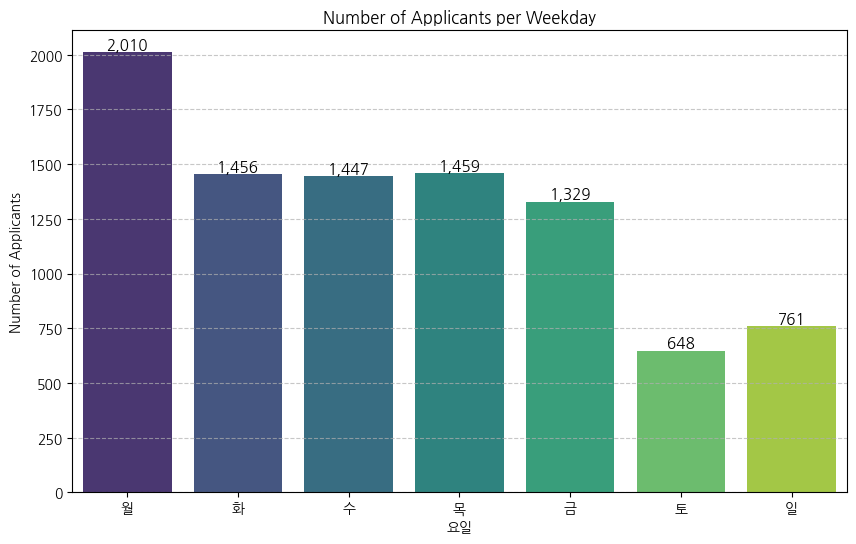

In [105]:
# 요일별 신규 신청자 수 시각화
applicants_by_weekday = register_df.groupby('trial_weekday')['user_uuid'].nunique().reset_index()
applicants_by_weekday.columns = ['Weekday', 'Number of Applicants']

weekday_order = ['월', '화', '수', '목', '금', '토', '일']
applicants_by_weekday['Weekday'] = pd.Categorical(applicants_by_weekday['Weekday'], categories=weekday_order, ordered=True)
applicants_by_weekday = applicants_by_weekday.sort_values('Weekday')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Weekday', y='Number of Applicants', data=applicants_by_weekday, palette='viridis', hue='Weekday', legend=False)

# 수치 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('Number of Applicants per Weekday')
plt.xlabel('요일')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 결제자 vs 미결제자

In [106]:
#사용자별 방문 집계
user_visit = (
    visit_info_df
    .groupby('user_uuid', as_index=False)
    .agg(
        visit_days=('date', 'count'),          # 날짜 컬럼명 확인 필요
        total_stay=('stay_time_second', 'sum'),
        avg_stay=('stay_time_second', 'mean')
    )
)

#payment_log_df 기준으로 left merge
eda_df = payment_log_df.merge(
    user_visit,
    on='user_uuid',
    how='left'
)

#방문 기록 없는 사람 처리
eda_df['visit_days'] = eda_df['visit_days'].fillna(0)
eda_df['total_stay'] = eda_df['total_stay'].fillna(0)
eda_df['avg_stay'] = eda_df['avg_stay'].fillna(0)

# 전체 count 확인
print("payment_log_df 사용자 수:", payment_log_df['user_uuid'].nunique())
print("eda_df 행 수:", len(eda_df))
print("eda_df 사용자 수:", eda_df['user_uuid'].nunique())

# 결제/미결제별 비교
eda_summary = (
    eda_df.groupby('is_payment')[['visit_days', 'total_stay', 'avg_stay']]
    .agg(['count', 'mean','median'])
    .round(2)
    .T
)

eda_summary.columns = ['미결제', '결제']

eda_summary

payment_log_df 사용자 수: 9110
eda_df 행 수: 9110
eda_df 사용자 수: 9110


미결제        결제
visit_days count    5685.00   3425.00
           mean        1.11      1.35
           median      1.00      1.00
total_stay count    5685.00   3425.00
           mean    19934.56  20719.41
           median  10442.00  11776.00
avg_stay   count    5685.00   3425.00
           mean    10973.82  10073.16
           median   8527.00   7956.33

💡 결제자는 미결제자보다 평균 방문일수(1.35일 vs 1.11일)와 평균 총체류시간(20,719초 vs 19,935초)이 모두 높음 — 체험 기간 중 더 자주, 더 오래 머문 유저일수록 결제 전환 가능성이 큼

### 출입횟수 평균

In [107]:
# 유저별 출입 횟수 집계 및 결제 여부 병합
access_count = (
    access_log_df
    .groupby('user_uuid')
    .size()
    .reset_index(name='access_count')
)

access_count = payment_log_df.merge(
    access_count,
    on='user_uuid',
    how='left'
)

access_count['access_count'] = access_count['access_count'].fillna(0)

access_count.groupby('is_payment')['access_count'].agg(['count','mean'])

,count,mean
is_payment,,
0,5685,6.833245
1,3425,7.145401


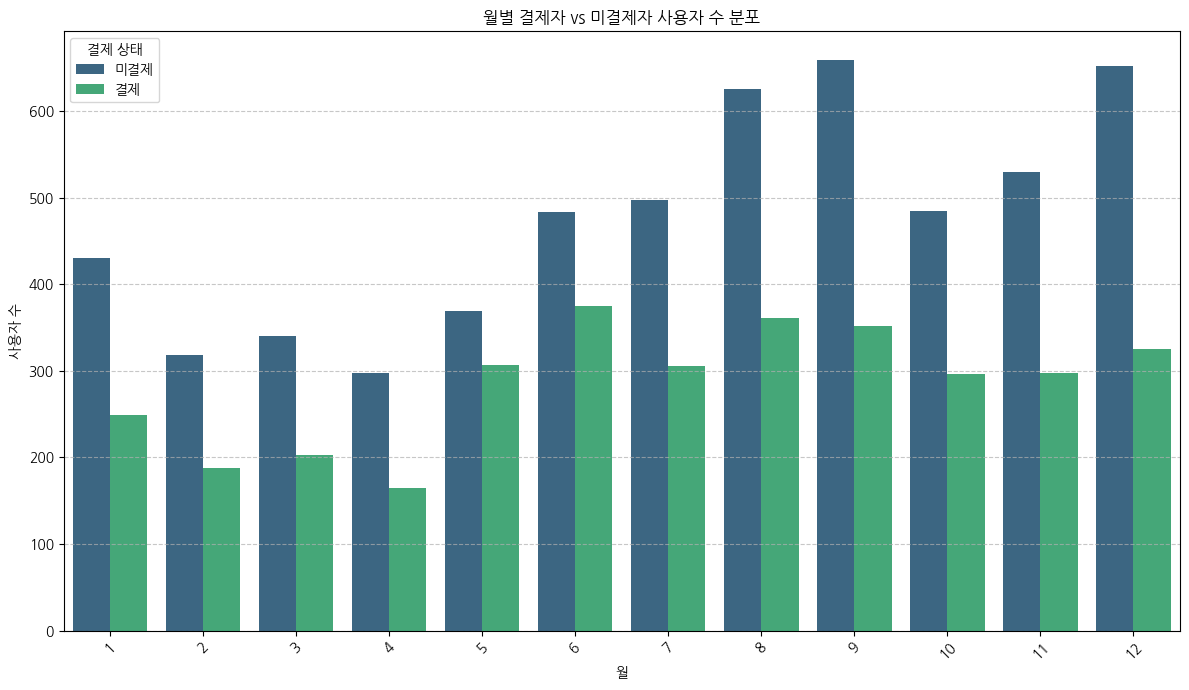

In [108]:
# 월별 결제자/미결제자 수 집계 및 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# payment_log_df와 register_df 병합
payment_register_merged = pd.merge(register_df, payment_log_df[['user_uuid', 'is_payment']], on='user_uuid', how='left')

# 월별 결제자/미결제자 수 집계
monthly_payment_counts = payment_register_merged.groupby(['trial_date_month', 'is_payment'])['user_uuid'].nunique().reset_index()
monthly_payment_counts.columns = ['Month', 'Payment Status', 'Number of Users']

# Payment Status를 '미결제'와 '결제'로 변경
monthly_payment_counts['Payment Status'] = monthly_payment_counts['Payment Status'].map({0: '미결제', 1: '결제'})

# 시각화
plt.figure(figsize=(12, 7))
sns.barplot(x='Month', y='Number of Users', hue='Payment Status', data=monthly_payment_counts, palette='viridis')
plt.title('월별 결제자 vs 미결제자 사용자 수 분포')
plt.xlabel('월')
plt.ylabel('사용자 수')
plt.xticks(rotation=45)
plt.legend(title='결제 상태')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 지점별 결제율

In [109]:
# 면적 크기 : 3,5,6 : 150, 2,4 : 100 , 1,17,47,49 : 50

#사용자별 첫 방문 지점 추출
first_site = (
    visit_info_df
    .sort_values('first_enter_time')
    .groupby('user_uuid', as_index=False)
    .first()[['user_uuid', 'site_id']]
)

#결제정보 병합
site_payment = first_site.merge(
    payment_log_df[['user_uuid', 'is_payment']],
    on='user_uuid',
    how='left'
)

#지점별 결제율 계산
site_payment_rate = (
    site_payment
    .groupby('site_id')
    .agg(
        사용자수=('user_uuid', 'count'),
        결제자수=('is_payment', 'sum'),
        결제율=('is_payment', 'mean')
    )
)

site_payment_rate['결제율'] = (
    site_payment_rate['결제율'] * 100
).round(2)

site_payment_rate = site_payment_rate.sort_values('결제율', ascending=False)

site_payment_rate

,사용자수,결제자수,결제율
site_id,,,
5,552,252,45.65
3,1227,517,42.14
49,129,54,41.86
1,759,311,40.97
4,464,186,40.09
2,1014,367,36.19
6,1166,411,35.25
17,421,146,34.68
47,291,93,31.96


💡 지점별 결제율은 31.96%(47번)~45.65%(5번)로 최대 13.7%p 차이 — 지점 간 결제율 편차가 생각보다 큼

### 방문 여부별

In [110]:
# 유저별 방문 회차 계산 및 방문 여부별 결제 비교 준비
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

visit_info_df_sorted = visit_info_df.sort_values(['user_uuid', 'date']).copy()
visit_info_df_sorted['visit_day_number'] = visit_info_df_sorted.groupby('user_uuid').cumcount() + 1

register_feat = register_df[['user_uuid', 'trial_date']].copy()

first_visit = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] == 1]
    [['user_uuid', 'first_enter_time']]
    .copy()
)
first_visit['첫방문일'] = pd.to_datetime(first_visit['first_enter_time']).dt.normalize()

days_to_first = register_feat[['user_uuid', 'trial_date']].merge(first_visit, on='user_uuid', how='left')
days_to_first['신청후첫방문일수'] = (
    (days_to_first['첫방문일'] - days_to_first['trial_date'])
    .dt.days.clip(lower=0)
)
days_to_first = days_to_first[['user_uuid', '신청후첫방문일수']]

payment_label = payment_log_df[['user_uuid', 'is_payment']].drop_duplicates('user_uuid')

plot_data_for_viz = payment_label.merge(days_to_first, on='user_uuid', how='left')

plot_data_for_viz['방문여부'] = np.where(plot_data_for_viz['신청후첫방문일수'].notna(), 1, 0)

visit_payment_counts = plot_data_for_viz.groupby(['방문여부', 'is_payment'])['user_uuid'].nunique().reset_index()
visit_payment_counts.columns = ['Visit Status', 'Payment Status', 'Number of Users']

visit_payment_counts['Visit Status'] = visit_payment_counts['Visit Status'].map({0: '미방문', 1: '방문'})
visit_payment_counts['Payment Status'] = visit_payment_counts['Payment Status'].map({0: '미결제', 1: '결제'})

visit_payment_counts['Percentage'] = visit_payment_counts.groupby('Visit Status')['Number of Users'].transform(lambda x: x / x.sum() * 100)

display(visit_payment_counts)

,Visit Status,Payment Status,Number of Users,Percentage
0,미방문,미결제,2003,64.801035
1,미방문,결제,1088,35.198965
2,방문,미결제,3682,61.172952
3,방문,결제,2337,38.827048


### 3일차까지의 체류시간별 결제

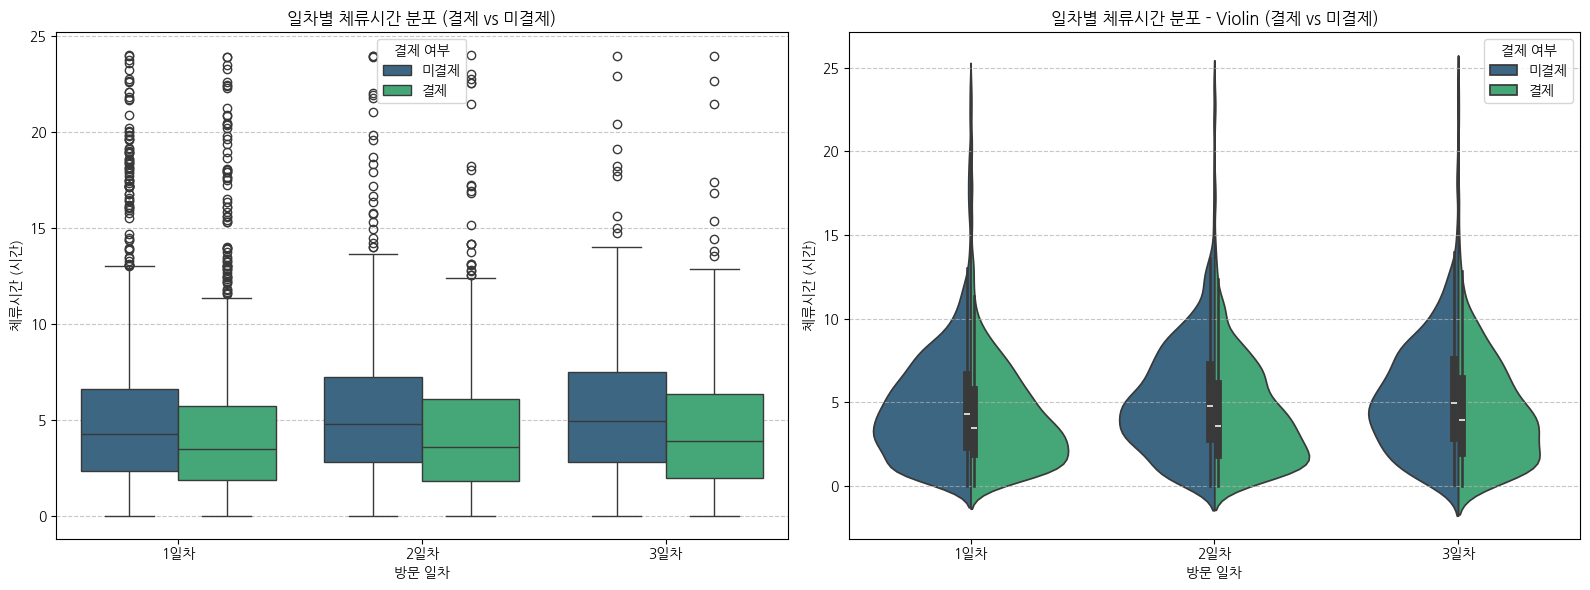

mean  median   std
visit_day_number is_payment                    
1일차              결제          4.18    3.47  3.28
                 미결제         4.78    4.28  3.38
2일차              결제          4.21    3.59  3.15
                 미결제         5.19    4.76  3.35
3일차              결제          4.43    3.91  3.21
                 미결제         5.36    4.95  3.40

In [111]:
# stay_time_hours 컬럼 생성
visit_info_df['stay_time_hours'] = visit_info_df['stay_time_second'] / 3600

# visit_info_df_sorted에 붙이기
visit_info_df_sorted = visit_info_df_sorted.merge(
    visit_info_df[['user_uuid', 'date', 'stay_time_hours']],
    on=['user_uuid', 'date'],
    how='left'
)

day_stay_long = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] <= 3]
    .merge(payment_label, on='user_uuid', how='left')
)

day_stay_long['is_payment'] = day_stay_long['is_payment'].map({0: '미결제', 1: '결제'})
day_stay_long['visit_day_number'] = day_stay_long['visit_day_number'].astype(str) + '일차'

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(
    x='visit_day_number', y='stay_time_hours',
    hue='is_payment', data=day_stay_long,
    palette='viridis', ax=axes[0]
)
axes[0].set_title('일차별 체류시간 분포 (결제 vs 미결제)')
axes[0].set_xlabel('방문 일차')
axes[0].set_ylabel('체류시간 (시간)')
axes[0].legend(title='결제 여부')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Violin (분포 형태까지 확인)
sns.violinplot(
    x='visit_day_number', y='stay_time_hours',
    hue='is_payment', data=day_stay_long,
    palette='viridis', split=True, ax=axes[1]
)
axes[1].set_title('일차별 체류시간 분포 - Violin (결제 vs 미결제)')
axes[1].set_xlabel('방문 일차')
axes[1].set_ylabel('체류시간 (시간)')
axes[1].legend(title='결제 여부')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 수치 요약
summary = (
    day_stay_long.groupby(['visit_day_number', 'is_payment'])['stay_time_hours']
    .agg(['mean', 'median', 'std'])
    .round(2)
)
display(summary)

,미결제,결제
visit_count,,
1,1860,849
2,1121,811
3,690,607


,visit_count,user_count,payment_user_count,payment_rate
0,1,2709,849,31.34
1,2,1932,811,41.98
2,3,1297,607,46.80


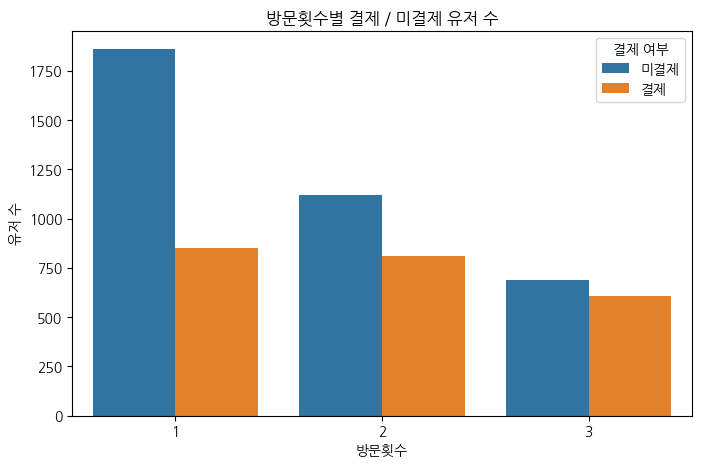

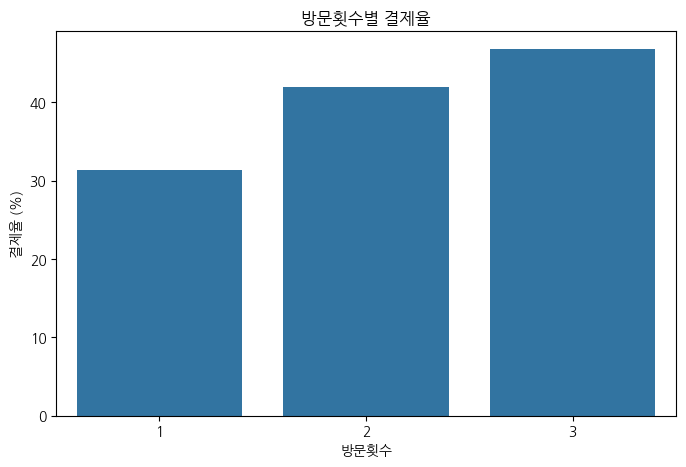

In [112]:
# 1. 날짜 타입 변환
visit_info_df['date'] = pd.to_datetime(visit_info_df['date'])

# 2. 유저별 방문횟수 계산
visit_count_user = (
    visit_info_df
    .groupby('user_uuid')
    .agg(
        visit_count=('date', 'nunique')
    )
    .reset_index()
)

# 3. 유저별 결제 여부 계산
payment_user = (
    payment_log_df
    .groupby('user_uuid')
    .agg(
        is_payment=('is_payment', 'max')
    )
    .reset_index()
)

# 4. 방문횟수 + 결제 여부 merge
visit_payment_user = visit_count_user.merge(
    payment_user,
    on='user_uuid',
    how='left'
)

visit_payment_user['is_payment'] = visit_payment_user['is_payment'].fillna(0).astype(int)

# 5. 1회 / 2회 / 3회 방문자만 필터링
visit_123 = visit_payment_user[
    visit_payment_user['visit_count'].isin([1, 2, 3])
].copy()

# 6. 방문횟수별 결제 / 미결제 인원 수
visit_payment_pivot = pd.crosstab(
    visit_123['visit_count'],
    visit_123['is_payment']
)

visit_payment_pivot.columns = ['미결제', '결제']

display(visit_payment_pivot)

# 7. 방문횟수별 결제율
visit_payment_rate = (
    visit_123
    .groupby('visit_count')
    .agg(
        user_count=('user_uuid', 'count'),
        payment_user_count=('is_payment', 'sum'),
        payment_rate=('is_payment', 'mean')
    )
    .reset_index()
)

visit_payment_rate['payment_rate'] = visit_payment_rate['payment_rate'] * 100

display(visit_payment_rate.round(2))

# 8. 결제 / 미결제 인원 수 시각화
plt.figure(figsize=(8, 5))

sns.countplot(
    data=visit_123,
    x='visit_count',
    hue='is_payment'
)

plt.title('방문횟수별 결제 / 미결제 유저 수')
plt.xlabel('방문횟수')
plt.ylabel('유저 수')
plt.legend(title='결제 여부', labels=['미결제', '결제'])
plt.show()

# 9. 방문횟수별 결제율 시각화
plt.figure(figsize=(8, 5))

sns.barplot(
    data=visit_payment_rate,
    x='visit_count',
    y='payment_rate'
)

plt.title('방문횟수별 결제율')
plt.xlabel('방문횟수')
plt.ylabel('결제율 (%)')
plt.show()

### 신청요일별 결제 / 미결제

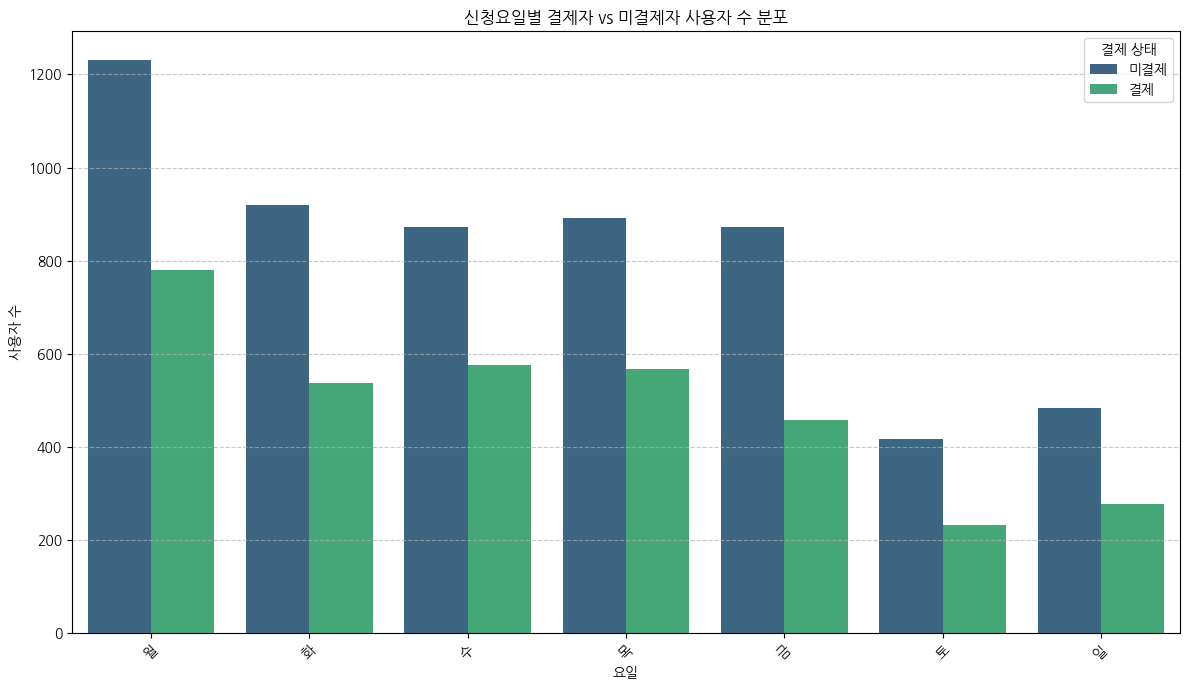

In [113]:
# 신청 요일별 결제자/미결제자 수 집계 및 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#payment_log_df와 register_df 병합
payment_by_weekday = pd.merge(register_df, payment_log_df[['user_uuid', 'is_payment']], on='user_uuid', how='left')

#요일별 결제자/미결제자 수 집계
weekday_payment_counts = payment_by_weekday.groupby(['trial_weekday', 'is_payment'])['user_uuid'].nunique().reset_index()
weekday_payment_counts.columns = ['Weekday', 'Payment Status', 'Number of Users']

#Payment Status를 '미결제'와 '결제'로 변경
weekday_payment_counts['Payment Status'] = weekday_payment_counts['Payment Status'].map({0: '미결제', 1: '결제'})

#요일 순서 정의 (월요일부터 일요일)
weekday_order = ['월', '화', '수', '목', '금', '토', '일']
weekday_payment_counts['Weekday'] = pd.Categorical(weekday_payment_counts['Weekday'], categories=weekday_order, ordered=True)
weekday_payment_counts = weekday_payment_counts.sort_values('Weekday')

#시각화
plt.figure(figsize=(12, 7))
sns.barplot(x='Weekday', y='Number of Users', hue='Payment Status', data=weekday_payment_counts, palette='viridis')
plt.title('신청요일별 결제자 vs 미결제자 사용자 수 분포')
plt.xlabel('요일')
plt.ylabel('사용자 수')
plt.xticks(rotation=45)
plt.legend(title='결제 상태')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 주말방문포함 결제 / 미결제

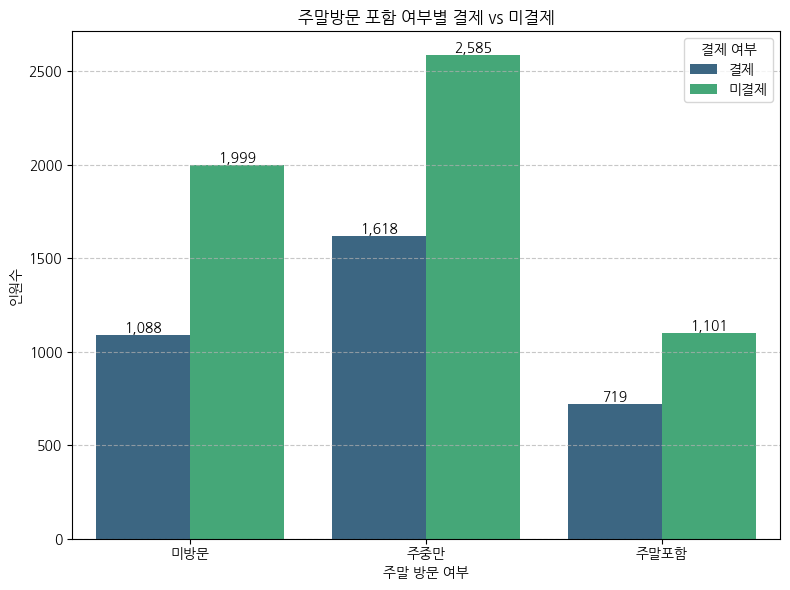


── 주말방문포함 결제율 ──


is_payment,결제(%),미결제(%)
주말방문포함_label,,
미방문,35.2,64.8
주중만,38.5,61.5
주말포함,39.5,60.5


In [114]:
# ── 주말방문포함 여부별 결제 vs 미결제 ──
visit_info_df_sorted['요일'] = pd.to_datetime(visit_info_df_sorted['date']).dt.dayofweek

weekend_visit = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] <= 3]
    .groupby('user_uuid')['요일']
    .apply(lambda x: int((x >= 5).any()))
    .reset_index(name='주말방문포함')
)

plot_df = register_df[['user_uuid']].merge(weekend_visit, on='user_uuid', how='left')
plot_df['주말방문포함'] = plot_df['주말방문포함'].fillna(-1).astype(int)
plot_df = plot_df.merge(payment_label, on='user_uuid', how='left')
plot_df['is_payment'] = plot_df['is_payment'].map({0: '미결제', 1: '결제'})
plot_df['주말방문포함_label'] = plot_df['주말방문포함'].map({-1: '미방문', 0: '주중만', 1: '주말포함'})

weekend_counts = (
    plot_df.groupby(['주말방문포함_label', 'is_payment'])['user_uuid']
    .count()
    .reset_index(name='인원수')
)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='주말방문포함_label', y='인원수', hue='is_payment',
                 data=weekend_counts, palette='viridis',
                 order=['미방문', '주중만', '주말포함'])
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)
ax.set_title('주말방문 포함 여부별 결제 vs 미결제')
ax.set_xlabel('주말 방문 여부')
ax.set_ylabel('인원수')
ax.legend(title='결제 여부')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\n── 주말방문포함 결제율 ──')
display(
    plot_df.groupby('주말방문포함_label')['is_payment']
    .value_counts(normalize=True).mul(100).round(1)
    .unstack().rename(columns={'결제': '결제(%)', '미결제': '미결제(%)'})
    .reindex(['미방문', '주중만', '주말포함'])
)

### 신청 후 첫방문 결제 / 미결제

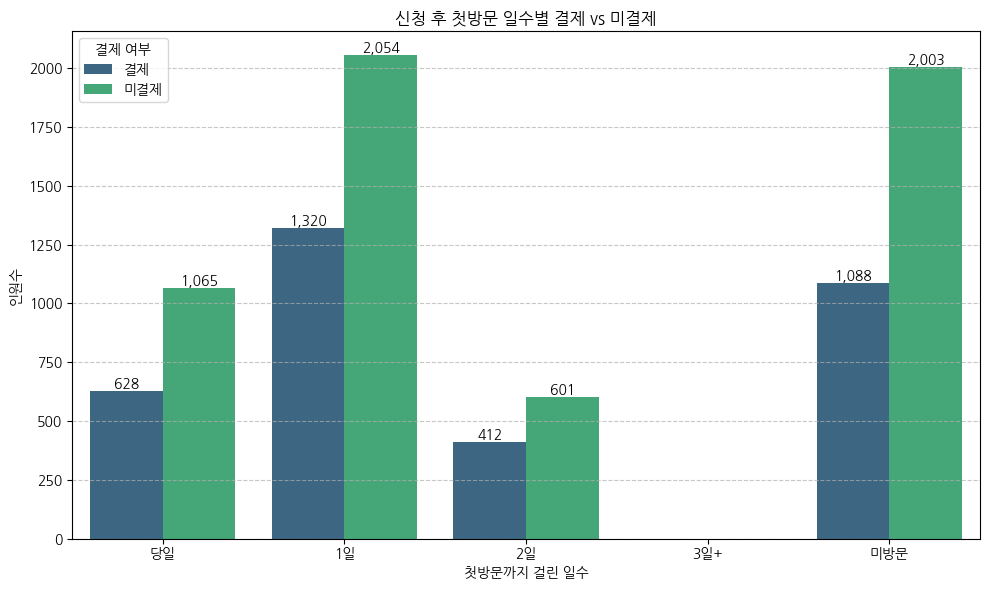


── 첫방문 일수 결제율 ──


is_payment,결제(%),미결제(%)
첫방문구간,,
당일,37.1,62.9
1일,39.1,60.9
2일,40.7,59.3
3일+,NaN,NaN
미방문,35.2,64.8


In [115]:
# ── 3. 신청 후 첫방문 일수별 결제 vs 미결제 ──────────────
# 필요한 데이터만 조합
first_visit = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] == 1]
    [['user_uuid', 'first_enter_time']].copy()
)
first_visit['첫방문일'] = pd.to_datetime(first_visit['first_enter_time']).dt.normalize()

days_to_first = register_df[['user_uuid', 'trial_date']].merge(first_visit, on='user_uuid', how='left')
days_to_first['신청후첫방문일수'] = (
    (days_to_first['첫방문일'] - days_to_first['trial_date'])
    .dt.days.clip(lower=0)
)

plot_df = days_to_first[['user_uuid', '신청후첫방문일수']].merge(payment_label, on='user_uuid', how='left')
plot_df['is_payment'] = plot_df['is_payment'].map({0: '미결제', 1: '결제'})

def bin_days(x):
    if pd.isna(x): return '미방문'
    elif x == 0: return '당일'
    elif x == 1: return '1일'
    elif x == 2: return '2일'
    else: return '3일+'

plot_df['첫방문구간'] = plot_df['신청후첫방문일수'].apply(bin_days)
day_order = ['당일', '1일', '2일', '3일+', '미방문']

first_visit_counts = (
    plot_df.groupby(['첫방문구간', 'is_payment'])['user_uuid']
    .count()
    .reset_index(name='인원수')
)
first_visit_counts['첫방문구간'] = pd.Categorical(first_visit_counts['첫방문구간'], categories=day_order, ordered=True)
first_visit_counts = first_visit_counts.sort_values('첫방문구간')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='첫방문구간', y='인원수', hue='is_payment', data=first_visit_counts, palette='viridis')
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)
ax.set_title('신청 후 첫방문 일수별 결제 vs 미결제')
ax.set_xlabel('첫방문까지 걸린 일수')
ax.set_ylabel('인원수')
ax.legend(title='결제 여부')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\n── 첫방문 일수 결제율 ──')
display(
    plot_df.groupby('첫방문구간')['is_payment']
    .value_counts(normalize=True).mul(100).round(1)
    .unstack().rename(columns={'결제': '결제(%)', '미결제': '미결제(%)'})
    .reindex(day_order)
)

In [164]:
# 신청 후 첫방문 구간별 결제/미결제 인원수 및 결제율 집계
count_table = pd.crosstab(
    plot_df['첫방문구간'],
    plot_df['is_payment']
).reindex(day_order)

rate_table = (
    count_table
    .div(count_table.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

display(count_table)
display(rate_table)

is_payment,결제,미결제
첫방문구간,,
당일,628.0,1065.0
1일,1320.0,2054.0
2일,412.0,601.0
3일+,NaN,NaN
미방문,1088.0,2003.0


is_payment,결제,미결제
첫방문구간,,
당일,37.1,62.9
1일,39.1,60.9
2일,40.7,59.3
3일+,NaN,NaN
미방문,35.2,64.8


### stay_time 분포 시각화

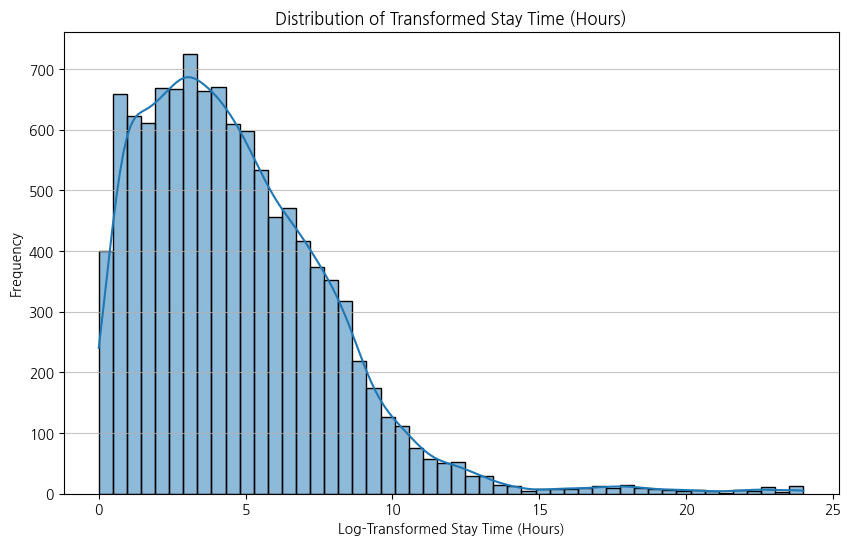

In [116]:
# 전체 방문 기록 기준 체류시간(시간 단위) 분포 시각화
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

visit_info_df['stay_time_hours'] = visit_info_df['stay_time_second'] / 3600

plt.figure(figsize=(10, 6))
sns.histplot(visit_info_df['stay_time_hours'], bins=50, kde=True)
plt.title('Distribution of Transformed Stay Time (Hours)')
plt.xlabel('Log-Transformed Stay Time (Hours)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

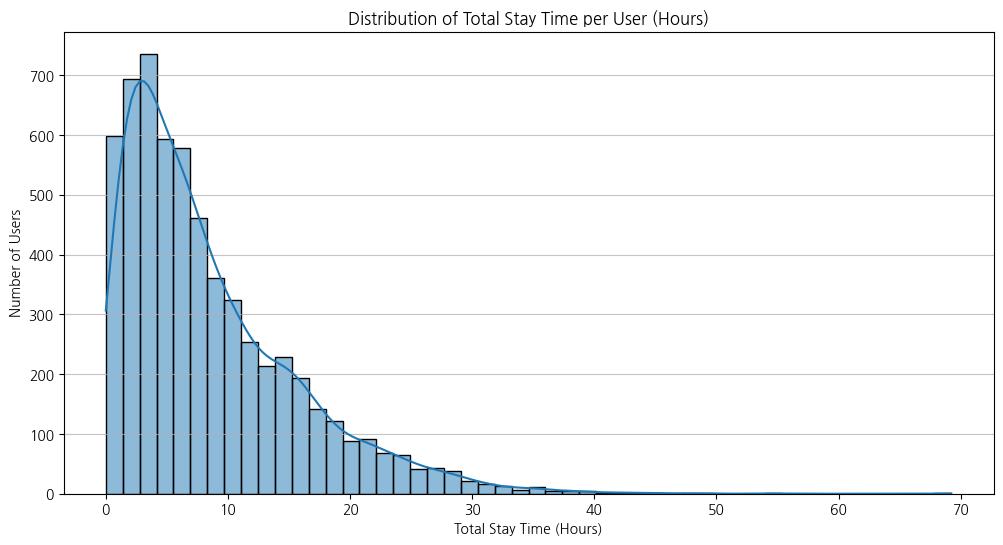

In [117]:
# 사용자별 총 체류시간 분포 시각화
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 사용자별 총 체류 시간(시간 단위) 집계
stay_time_per_user = visit_info_df.groupby('user_uuid')['stay_time_hours'].sum().reset_index()

# 2. 시각화 (로그 변환 없이 수행)
plt.figure(figsize=(12, 6))
sns.histplot(stay_time_per_user['stay_time_hours'], bins=50, kde=True)
plt.title('Distribution of Total Stay Time per User (Hours)')
plt.xlabel('Total Stay Time (Hours)')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()

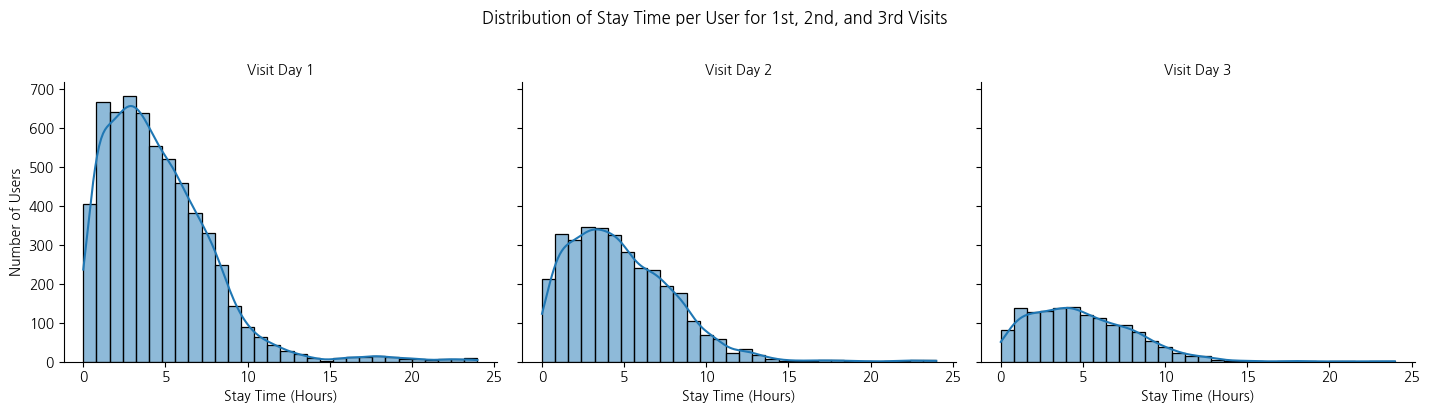

In [118]:
# 1. 방문 회차(visit_day_number) 계산 및 1~3회차 필터링
visit_info_df_sorted = visit_info_df.sort_values(['user_uuid', 'date'])
visit_info_df_sorted['visit_day_number'] = visit_info_df_sorted.groupby('user_uuid').cumcount() + 1
first_three_visits = visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] <= 3]

# 2. 시각화 (로그 변환 없이 수행)
g = sns.FacetGrid(first_three_visits, col='visit_day_number', col_wrap=3, height=4, aspect=1.2)
g.map(sns.histplot, 'stay_time_hours', bins=30, kde=True)
g.set_axis_labels('Stay Time (Hours)', 'Number of Users')
g.set_titles('Visit Day {col_name}')
plt.suptitle('Distribution of Stay Time per User for 1st, 2nd, and 3rd Visits', y=1.02)
plt.tight_layout()
plt.show()

### 신청 후 첫 방문까지 걸린 시간 시각화

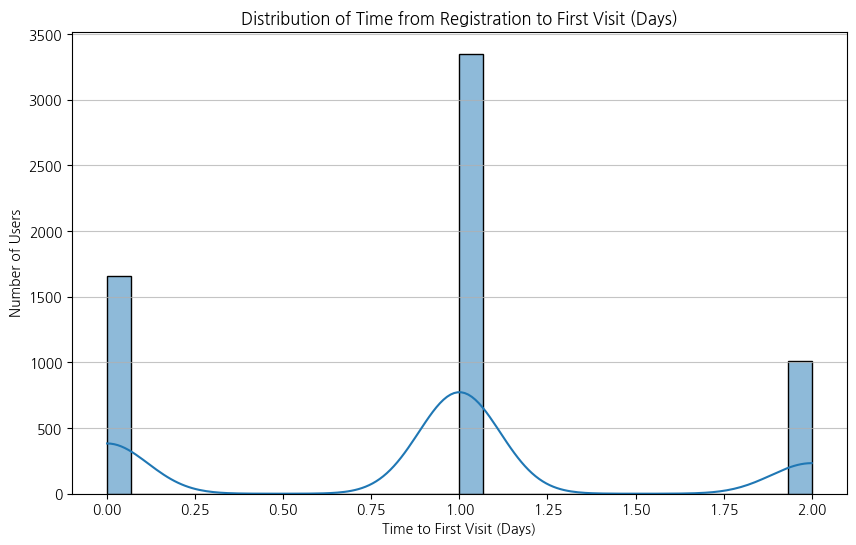

In [119]:
# visit_info_df_sorted에서 각 user_uuid의 첫 방문 기록(visit_day_number == 1)만 필터링합니다.
first_visit_df = visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] == 1].copy()

# register_df와 first_visit_df를 user_uuid 기준으로 병합
merged_df = pd.merge(register_df, first_visit_df, on='user_uuid', how='inner')

# first_enter_time의 timezone 제거 (trial_date와 연산하기 위함)
merged_df['first_enter_time_naive'] = merged_df['first_enter_time'].dt.tz_localize(None)

# 신청일로부터 첫 방문까지 걸린 시간 계산 (일 단위)
merged_df['time_to_first_visit_days'] = (merged_df['first_enter_time_naive'].dt.normalize() - merged_df['trial_date']).dt.days

# 음수 값이 있다면 (첫 방문일이 신청일보다 빠른 경우) 0으로 처리
merged_df['time_to_first_visit_days'] = merged_df['time_to_first_visit_days'].clip(lower=0)

# 시각화
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['time_to_first_visit_days'], bins=30, kde=True)
plt.title('Distribution of Time from Registration to First Visit (Days)')
plt.xlabel('Time to First Visit (Days)')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 파생변수 생성

In [120]:
# 각 user_uuid별 고유한 방문일수를 계산합니다.
visit_days_per_user = visit_info_df.groupby('user_uuid')['date'].nunique().reset_index(name='방문일수')

# 계산된 방문일수를 visit_info_df에 user_uuid를 기준으로 병합합니다.
visit_info_df = pd.merge(visit_info_df, visit_days_per_user, on='user_uuid', how='left')

# 결과 확인
display(visit_info_df.head())

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid,stay_time_hours,방문일수
0,1,2023-12-23,0 days 01:11:19,4279,2023-12-23 16:11:25,2023-12-23 17:25:32,939fc566-61cd-47f0-a3ce-e2936fdcff73,1.188611,3
1,1,2023-12-24,0 days 04:35:10,16510,2023-12-24 16:10:45,2023-12-24 20:53:34,939fc566-61cd-47f0-a3ce-e2936fdcff73,4.586111,3
2,1,2023-12-25,0 days 02:09:54,7794,2023-12-25 10:19:47,2023-12-25 12:39:51,939fc566-61cd-47f0-a3ce-e2936fdcff73,2.165000,3
3,1,2023-12-23,0 days 04:37:36,16656,2023-12-23 14:49:40,2023-12-23 19:27:39,ba49324f-d317-4053-adf9-2b17b3f07594,4.626667,3
4,3,2023-12-26,0 days 04:32:05,16325,2023-12-26 14:57:10,2023-12-26 19:34:36,ba49324f-d317-4053-adf9-2b17b3f07594,4.534722,3


In [121]:
# 유저별 방문일수 요약 확인
user_visit_summary = visit_days_per_user[['user_uuid', '방문일수']]
display(user_visit_summary.head())

,user_uuid,방문일수
0,000590dc-046f-462b-8225-4c81a97b7166,1
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,3
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,2
3,002606d9-38ca-48f3-910c-cbfada9a9109,2
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,2


In [122]:
# 모델링용 파생 피처 집계 시작 (방문일수, 체류시간 등)
import pandas as pd
import numpy as np

# ── 1. 방문일수 ──────────────────────────────────────────
visit_days = user_visit_summary[['user_uuid', '방문일수']]
# ── 2. 체류시간 관련 ─────────────────────────────────────

stay = (
    visit_info_df.groupby('user_uuid')['stay_time_hours']
    .agg( 일평균체류시간='mean', 총체류시간='sum' )
    .round(2)
    .reset_index()
)

# ── 3. 일차별 체류시간 (visit_day_number 1,2,3) ───────────
day_stay = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] <= 3]
    .pivot_table(index='user_uuid', columns='visit_day_number',
                 values='stay_time_hours', aggfunc='sum')
    .rename(columns={1: '1일차_체류시간', 2: '2일차_체류시간', 3: '3일차_체류시간'})
    .round(2)
    .reset_index()
)

# ── 4. 출입횟수 (access_log 전체 로그 기준) ──────────────
access_daily = access_log_df.copy()
access_daily['date'] = access_daily['cdate'].dt.normalize()

daily_access_count = (
    access_daily.groupby(['user_uuid', 'date'])
    .size()
    .reset_index(name='일별출입횟수')
)

# visit_day_number 매핑
day_map = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] <= 3]
    [['user_uuid', 'date', 'visit_day_number']]
    .copy()
)
day_map['date'] = pd.to_datetime(day_map['date']).dt.tz_localize(None)
daily_access_count['date'] = pd.to_datetime(daily_access_count['date']).dt.tz_localize(None)

daily_access_count = daily_access_count.merge(day_map, on=['user_uuid', 'date'], how='left')

access_by_day = (
    daily_access_count[daily_access_count['visit_day_number'].notna()]
    .pivot_table(index='user_uuid', columns='visit_day_number',
                 values='일별출입횟수', aggfunc='sum')
    .rename(columns={1.0: '1일차_출입횟수', 2.0: '2일차_출입횟수', 3.0: '3일차_출입횟수'})
    .reset_index()
)

# 3일 합계 출입횟수
access_total = (
    access_log_df.groupby('user_uuid')
    .size()
    .reset_index(name='총출입횟수')
)

# ── 5. 지점ID & 면적 ─────────────────────────────────────
AREA_COL = 'area_pyeong'  # ← area_df 면적 컬럼명으로 변경

site = (
    access_log_df.groupby('user_uuid')['site_id']
    .agg(lambda x: x.mode()[0])
    .reset_index(name='site_id')
)
site = site.merge(area_df[['site_id', AREA_COL]], on='site_id', how='left')
site = site.rename(columns={'site_id': '지점ID', AREA_COL: '면적'})

# ── 6. 신청 요일 ─────────────────────────────────────────
register_feat = register_df[['user_uuid', 'trial_date']].copy()
register_feat['신청요일'] = register_feat['trial_date'].dt.dayofweek  # 0=월 ~ 6=일

# ── 7. 주말 방문 포함 여부 ───────────────────────────────
visit_info_df_sorted['요일'] = pd.to_datetime(visit_info_df_sorted['date']).dt.dayofweek

weekend_visit = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] <= 3]
    .groupby('user_uuid')['요일']
    .apply(lambda x: int((x >= 5).any()))
    .reset_index(name='주말방문포함')
)

# ── 8. 신청 후 첫 방문까지 걸린 일수 ────────────────────
first_visit = (
    visit_info_df_sorted[visit_info_df_sorted['visit_day_number'] == 1]
    [['user_uuid', 'first_enter_time']]
    .copy()
)
first_visit['첫방문일'] = pd.to_datetime(first_visit['first_enter_time']).dt.normalize()

days_to_first = register_feat[['user_uuid', 'trial_date']].merge(first_visit, on='user_uuid', how='left')
days_to_first['신청후첫방문일수'] = (
    (days_to_first['첫방문일'] - days_to_first['trial_date'])
    .dt.days.clip(lower=0)
)
days_to_first = days_to_first[['user_uuid', '신청후첫방문일수']]

# ── 최종 병합 ────────────────────────────────────────────
feature_df = register_feat[['user_uuid', '신청요일']]

for df in [visit_days, stay, day_stay,
           access_by_day, access_total,
           site[['user_uuid', '지점ID', '면적']],
           weekend_visit, days_to_first]:
    feature_df = feature_df.merge(df, on='user_uuid', how='left')

# payment는 별도 df
payment_label = payment_log_df[['user_uuid', 'is_payment']].drop_duplicates('user_uuid')

print(feature_df.shape)
display(feature_df.head())
print(feature_df.isnull().sum())

(9110, 16)


,user_uuid,신청요일,방문일수,일평균체류시간,총체류시간,1일차_체류시간,2일차_체류시간,3일차_체류시간,1일차_출입횟수,2일차_출입횟수,3일차_출입횟수,총출입횟수,지점ID,면적,주말방문포함,신청후첫방문일수
0,badbde4d-886b-4992-a8e3-fd0c05640183,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e079e682-62f2-4c05-84b9-86913e3dc146,5,1.0,2.75,2.75,2.75,NaN,NaN,6.0,NaN,NaN,6.0,3.0,150.0,1.0,1.0
2,f25078d1-1030-485c-85c5-dc82d6987043,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,844319ff-cd15-4633-9900-6eaf4dc68b68,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


user_uuid       0
신청요일            0
방문일수         3087
일평균체류시간      3087
총체류시간        3087
1일차_체류시간     3087
2일차_체류시간     5769
3일차_체류시간     7691
1일차_출입횟수     3087
2일차_출입횟수     6456
3일차_출입횟수     8671
총출입횟수        3087
지점ID         3087
면적           3087
주말방문포함       3087
신청후첫방문일수     3091
dtype: int64


In [123]:
# 방문 여부 파생 컬럼 생성 및 결측치 처리
feature_df['방문여부'] = np.where(feature_df['신청후첫방문일수'].notna(), 1, 0)
feature_df = feature_df.fillna(-1)

print(feature_df.isnull().sum())
display(feature_df)

user_uuid    0
신청요일         0
방문일수         0
일평균체류시간      0
총체류시간        0
1일차_체류시간     0
2일차_체류시간     0
3일차_체류시간     0
1일차_출입횟수     0
2일차_출입횟수     0
3일차_출입횟수     0
총출입횟수        0
지점ID         0
면적           0
주말방문포함       0
신청후첫방문일수     0
방문여부         0
dtype: int64


,user_uuid,신청요일,방문일수,일평균체류시간,총체류시간,1일차_체류시간,2일차_체류시간,3일차_체류시간,1일차_출입횟수,2일차_출입횟수,3일차_출입횟수,총출입횟수,지점ID,면적,주말방문포함,신청후첫방문일수,방문여부
0,badbde4d-886b-4992-a8e3-fd0c05640183,5,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
1,e079e682-62f2-4c05-84b9-86913e3dc146,5,1.0,2.75,2.75,2.75,-1.00,-1.00,6.0,-1.0,-1.0,6.0,3.0,150.0,1.0,1.0,1
2,f25078d1-1030-485c-85c5-dc82d6987043,5,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
3,844319ff-cd15-4633-9900-6eaf4dc68b68,5,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
4,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,5,-1.0,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9105,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2,5,3.0,3.60,10.81,3.51,3.31,3.99,10.0,8.0,6.0,24.0,4.0,100.0,1.0,0.0,1
9106,aa4773c8-dbc9-4c80-849b-1ab8d1db7bda,5,1.0,3.29,3.29,3.29,-1.00,-1.00,6.0,-1.0,-1.0,6.0,3.0,150.0,0.0,2.0,1
9107,acf3e288-4487-492b-9477-df149fb72e83,6,2.0,5.33,10.65,6.62,4.03,-1.00,8.0,5.0,-1.0,13.0,6.0,150.0,1.0,0.0,1
9108,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8,6,2.0,5.35,10.70,2.98,7.73,-1.00,6.0,10.0,-1.0,16.0,3.0,150.0,1.0,0.0,1


##### 피쳐_변환: 출입당 체류시간

In [124]:
# 파생 피처 생성: 출입당 체류시간
feature_df['출입당체류시간'] = (
    feature_df['총체류시간'] /
    feature_df['총출입횟수'].replace(0, np.nan)
)

feature_df['출입당체류시간'] = (
    feature_df['출입당체류시간']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

##### 피쳐_변환: 하루 평균 출입횟수

In [125]:
# 파생 피처 생성: 하루 평균 출입횟수
feature_df['평균출입횟수'] = (
    feature_df['총출입횟수'] /
    feature_df['방문일수'].replace(0, np.nan)
)

feature_df['평균출입횟수'] = (
    feature_df['평균출입횟수']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

##### 피쳐_변환: 상호작용(Interaction)

In [126]:
# 파생 피처 생성: 방문일수와 총체류시간의 상호작용항
feature_df['방문일수X총체류시간'] = (
    feature_df['방문일수'] *
    feature_df['총체류시간']
)

In [127]:
# 파생 피처 생성: 방문당 체류시간
import numpy as np

feature_df['방문당체류시간'] = (
    feature_df['총체류시간'] /
    feature_df['방문일수'].replace(0, np.nan)
)

feature_df['방문당체류시간'] = (
    feature_df['방문당체류시간']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)